In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import re
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

数据集加载成功，共有 50000 行，2 列

数据集前5行:
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive

数据集信息:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB
None

数据集统计描述:
                                                   review sentiment
count                                               50000     50000
unique                                              49582         2
top     Loved today's show!!! It was a variety and not...

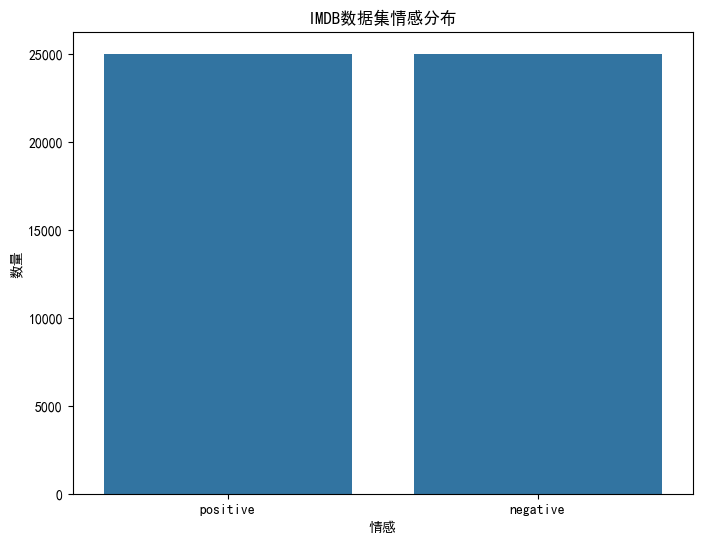

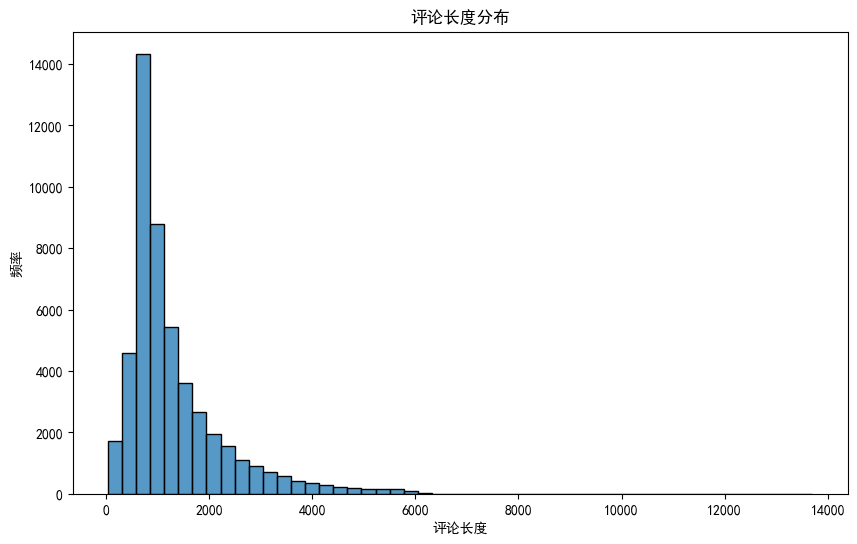

In [6]:
# 设置中文字体支持
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# 加载数据集
def load_dataset():
    try:
        df = pd.read_csv("IMDB Dataset.csv")
        print(f"数据集加载成功，共有 {df.shape[0]} 行，{df.shape[1]} 列")
        return df
    except Exception as e:
        print(f"加载数据集时出错: {e}")
        return None

# 数据探索
def explore_data(df):
    print("\n数据集前5行:")
    print(df.head())
    
    print("\n数据集信息:")
    print(df.info())
    
    print("\n数据集统计描述:")
    print(df.describe())
    
    print("\n检查缺失值:")
    print(df.isnull().sum())
    
    # 检查情感分布
    if 'sentiment' in df.columns:
        print("\n情感分布:")
        sentiment_counts = df['sentiment'].value_counts()
        print(sentiment_counts)
        
        # 绘制情感分布图
        plt.figure(figsize=(8, 6))
        sns.countplot(x='sentiment', data=df)
        plt.title('IMDB数据集情感分布')
        plt.xlabel('情感')
        plt.ylabel('数量')
        plt.savefig('sentiment_distribution.png')
        print("情感分布图已保存为 sentiment_distribution.png")
    
    # 检查评论长度分布
    if 'review' in df.columns:
        df['review_length'] = df['review'].apply(len)
        plt.figure(figsize=(10, 6))
        sns.histplot(df['review_length'], bins=50)
        plt.title('评论长度分布')
        plt.xlabel('评论长度')
        plt.ylabel('频率')
        plt.savefig('review_length_distribution.png')
        print("评论长度分布图已保存为 review_length_distribution.png")
        
        print("\n评论长度统计:")
        print(f"平均长度: {df['review_length'].mean()}")
        print(f"最大长度: {df['review_length'].max()}")
        print(f"最小长度: {df['review_length'].min()}")
        print(f"中位数长度: {df['review_length'].median()}")

# 加载数据集
df = load_dataset()
if df is not None:
    explore_data(df)

In [7]:
# 信息提取函数
def extract_information(df):
    print("\n开始信息提取任务...")
    
    if 'review' not in df.columns:
        print("数据集中没有'review'列，无法进行信息提取")
        return
    
    # 1. 提取评论中的电影名称（假设电影名称通常在引号中）
    def extract_movie_names(text):
        # 尝试提取引号中的内容作为电影名称
        movie_names = re.findall(r'\"([^\"]+)\"', text)
        return movie_names if movie_names else []
    
    # 2. 提取评论中提到的演员名字（这需要一个演员名单，这里简化处理）
    def extract_actors(text):
        # 这里简化处理，假设一些常见演员名字
        common_actors = ['Tom Hanks', 'Brad Pitt', 'Leonardo DiCaprio', 'Robert De Niro', 
                         'Al Pacino', 'Morgan Freeman', 'Meryl Streep', 'Jennifer Lawrence']
        mentioned_actors = [actor for actor in common_actors if actor.lower() in text.lower()]
        return mentioned_actors
    
    # 3. 提取评分相关信息
    def extract_ratings(text):
        # 尝试提取形如"X/10"或"X out of 10"的评分
        ratings = re.findall(r'(\d+(?:\.\d+)?)\s*(?:\/|\s*out\s*of\s*)\s*10', text.lower())
        return ratings if ratings else []
    
    # 应用提取函数到样本数据
    sample_size = min(100, len(df))  # 取前100条或全部数据
    sample_df = df.head(sample_size).copy()
    
    sample_df['extracted_movie_names'] = sample_df['review'].apply(extract_movie_names)
    sample_df['extracted_actors'] = sample_df['review'].apply(extract_actors)
    sample_df['extracted_ratings'] = sample_df['review'].apply(extract_ratings)
    
    # 统计提取结果
    movie_name_counts = sum(len(names) for names in sample_df['extracted_movie_names'])
    actor_counts = sum(len(actors) for actors in sample_df['extracted_actors'])
    rating_counts = sum(len(ratings) for ratings in sample_df['extracted_ratings'])
    
    print(f"从{sample_size}条评论中提取信息:")
    print(f"- 提取到{movie_name_counts}个可能的电影名称")
    print(f"- 提取到{actor_counts}个演员名字")
    print(f"- 提取到{rating_counts}个评分信息")
    
    # 保存一些提取结果示例
    print("\n信息提取示例:")
    for i in range(min(5, sample_size)):
        print(f"\n评论 {i+1}:")
        print(f"电影名称: {', '.join(sample_df['extracted_movie_names'].iloc[i])}")
        print(f"演员: {', '.join(sample_df['extracted_actors'].iloc[i])}")
        print(f"评分: {', '.join(sample_df['extracted_ratings'].iloc[i])}")
    
    return sample_df[['review', 'extracted_movie_names', 'extracted_actors', 'extracted_ratings']]

# 执行信息提取
if df is not None:
    extracted_info = extract_information(df)
    
    # 保存提取的信息到CSV文件
    if extracted_info is not None:
        extracted_info.to_csv('extracted_information.csv', index=False)
        print("\n提取的信息已保存到 extracted_information.csv")


开始信息提取任务...
从100条评论中提取信息:
- 提取到99个可能的电影名称
- 提取到1个演员名字
- 提取到16个评分信息

信息提取示例:

评论 1:
电影名称: 
演员: 
评分: 

评论 2:
电影名称: has got all the polari
演员: 
评分: 

评论 3:
电影名称: sexy, Devil Wears Prada, Superman
演员: 
评分: 

评论 4:
电影名称: 
演员: 
评分: 3

评论 5:
电影名称: Love in the Time of Money
演员: 
评分: 

提取的信息已保存到 extracted_information.csv



使用TensorFlow进行高级信息提取...
开始训练模型...
Epoch 1/5
1000/1000 [==============================] - 317s 314ms/step - loss: 0.0813 - accuracy: 0.9860 - val_loss: 0.0807 - val_accuracy: 0.9852
Epoch 2/5
1000/1000 [==============================] - 454s 455ms/step - loss: 0.0692 - accuracy: 0.9869 - val_loss: 0.0796 - val_accuracy: 0.9852
Epoch 3/5
1000/1000 [==============================] - 298s 298ms/step - loss: 0.0562 - accuracy: 0.9872 - val_loss: 0.0815 - val_accuracy: 0.9856
Epoch 4/5
1000/1000 [==============================] - 294s 294ms/step - loss: 0.0273 - accuracy: 0.9927 - val_loss: 0.0623 - val_accuracy: 0.9869
Epoch 5/5
313/313 [==============================] - 18s 57ms/step - loss: 0.0652 - accuracy: 0.9877
测试集准确率: 0.9877
模型性能图已保存为 tf_model_performance.png
313/313 [==============================] - 18s 56ms/step

预测包含演员信息的评论数量: 19

预测包含演员信息的评论示例:

评论 1:
预测概率: 0.5433
评论内容: I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned

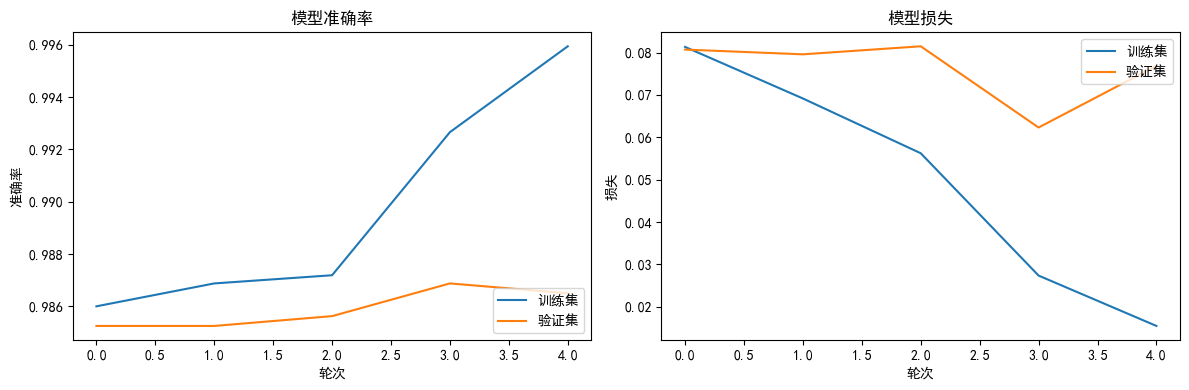

In [ ]:
# 使用TensorFlow进行信息提取
def tf_information_extraction(df):
    print("\n使用TensorFlow进行信息提取...")
    
    # 准备数据
    reviews = df['review'].values
    
    # 使用Tokenizer处理文本
    max_words = 10000  # 词汇表大小
    max_len = 200  # 序列最大长度
    
    tokenizer = Tokenizer(num_words=max_words)
    tokenizer.fit_on_texts(reviews)
    sequences = tokenizer.texts_to_sequences(reviews)
    padded_sequences = pad_sequences(sequences, maxlen=max_len)
    
    # 创建一个简单的分类模型来识别包含特定信息的评论
    # 例如：识别包含演员信息的评论
    
    # 创建标签（这里简化处理，假设包含常见演员名字的评论为正例）
    common_actors = ['Tom Hanks', 'Brad Pitt', 'Leonardo DiCaprio', 'Robert De Niro', 
                     'Al Pacino', 'Morgan Freeman', 'Meryl Streep', 'Jennifer Lawrence']
    
    labels = np.zeros(len(reviews))
    for i, review in enumerate(reviews):
        if any(actor.lower() in review.lower() for actor in common_actors):
            labels[i] = 1
    
    # 划分训练集和测试集
    X_train, X_test, y_train, y_test = train_test_split(padded_sequences, labels, test_size=0.2, random_state=42)
    
    # 构建模型
    model = Sequential()
    model.add(Embedding(max_words, 128, input_length=max_len))
    model.add(LSTM(64, dropout=0.2, recurrent_dropout=0.2))
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(1, activation='sigmoid'))
    
    # 编译模型
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    # 训练模型
    print("开始训练模型...")
    history = model.fit(X_train, y_train, batch_size=32, epochs=5, validation_split=0.2, verbose=1)
    
    # 评估模型
    score = model.evaluate(X_test, y_test, verbose=1)
    print(f"测试集准确率: {score[1]:.4f}")
    
    # 绘制训练过程
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('模型准确率')
    plt.ylabel('准确率')
    plt.xlabel('轮次')
    plt.legend(['训练集', '验证集'], loc='lower right')
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('模型损失')
    plt.ylabel('损失')
    plt.xlabel('轮次')
    plt.legend(['训练集', '验证集'], loc='upper right')
    
    plt.tight_layout()
    plt.savefig('tf_model_performance.png')
    print("模型性能图已保存为 tf_model_performance.png")
    
    # 使用模型预测
    predictions = model.predict(X_test)
    predicted_labels = (predictions > 0.5).astype(int).flatten()
    
    # 找出一些预测为包含演员信息的评论示例
    actor_reviews_indices = np.where(predicted_labels == 1)[0]
    print(f"\n预测包含演员信息的评论数量: {len(actor_reviews_indices)}")
    
    if len(actor_reviews_indices) > 0:
        print("\n预测包含演员信息的评论示例:")
        for i in range(min(5, len(actor_reviews_indices))):
            idx = actor_reviews_indices[i]
            original_idx = np.where(padded_sequences == X_test[idx])[0][0]
            print(f"\n评论 {i+1}:")
            print(f"预测概率: {predictions[idx][0]:.4f}")
            print(f"评论内容: {reviews[original_idx][:200]}...")
    
    return model, tokenizer

# 执行TensorFlow高级信息提取
if df is not None:
    tf_model, tf_tokenizer = tf_information_extraction(df)